<a href="https://colab.research.google.com/github/iamwekesa/Neural-Network-From-Scratch/blob/main/MNIST_from_Scratch_Building_My_First_Neural_Network_with_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Neural Network from Scratch


## The "No-Library" Challenge
Building a neural network from scratch means moving away from high-level abstractions like TensorFlow or PyTorch. Instead, we use Linear Algebra and Calculus to teach a computer how to recognize patterns. By using the MNIST dataset—a collection of 70,000 handwritten digits, we will create a model that learns to "see" numbers by adjusting its internal weights based on its own mistakes.

## Step 1: Data Preparation & Preprocessing

The goal of this step is to take raw image data and transform it into a format that a mathematical model can ingest. Data preprocessing is often 80% of the work in machine learning.

### 1.1 The Format of MNIS

Each MNIST image is a grayscale 28 \times 28 grid of pixels. In its raw form, each pixel has a value from 0 (black) to 255 (white). To process this, we "flatten" the grid into a single vector of 784 numbers ($28 \times 28 = 784$).

### 1.2 Shuffling

Data in datasets is often sorted. If we train on all the "0"s, then all the "1"s, the model will simply "forget" what a zero looks like by the time it reaches the end. Shuffling ensures that every batch the model sees contains a variety of digits, helping it generalize better.

### 1.3 Normalization

Neural networks are sensitive to the scale of input data. If inputs are large (like 255), the mathematical functions inside the network can "saturate," making it nearly impossible for the model to learn. By dividing every pixel by 255, we scale our inputs to a range between 0 and 1, which keeps our gradients stable.

### 1.4 The Transpose Operation

In deep learning math, it is standard practice to have each column represent a single training example and each row represent a feature (a pixel). Since CSV files usually store examples in rows, we use the Transpose function ($X^T$) to flip the matrix so the math aligns with standard neural network equations.

In [9]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # For visualizing the digits

In [20]:
# Load and Shuffle

# MNIST is built into every Colab instance under 'sample_data'

# 1. Load the dataset from Colab's built-in sample data
# The file contains 20,000 rows. Column 0 is the label, Columns 1-784 are pixels.
data = pd.read_csv('/content/sample_data/mnist_train_small.csv', header=None).values
m, n = data.shape


# 2. Shuffle the data
# This prevents the model from learning the order of the images
np.random.shuffle(data)

In [21]:
# Data Splitting and Normalization

# 3. Create a Development Set (1,000 images)
# We transpose (.T) so that each column is one image
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n] / 255.

# 4. Create the Training Set (Remaining 19,000 images)
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.

# 5. Verify the data
print(f"Training data shape: {X_train.shape}") # Should be (784, 19000)
print(f"Sample label: {Y_train[0]}")

Training data shape: (784, 19000)
Sample label: 1


You'll notice I used .T to transpose the data. In standard math notation for neural networks:

*   Each column represents one training example (one image).
*   Each row represents one feature (one pixel).





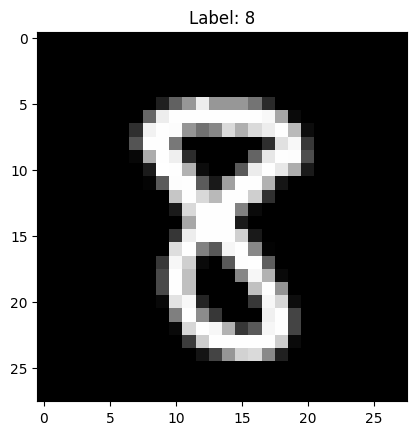

In [26]:
# Reshape the flattened 784 array back to 28x28 to view it
# 6. Optional: Visualize the first digit in the training set
plt.imshow(X_train[:, 7].reshape(28, 28), cmap='gray')
plt.title(f"Label: {Y_train[7]}")
plt.show()

## Step 2: Parameter Initialization

Now that the data is ready, we need to create the "brain" of our network. In a neural network, this consists of Weights ($W$) and Biases ($b$).

### 2.1 What are Weights and Biases?

- `Weights ($W$)`: These represent the strength of the connection between neurons. Initially, the network has no idea which pixels are important, so we assign random values.
- `Biases ($b$)`: These are added to the weighted sum of inputs to allow the activation function to shift left or right. Think of it as a "threshold" for a neuron to fire.

### 2.2 Why Randomize

If we initialize all weights to zero or the same number, every neuron in a layer will learn the exact same features during training (this is called the "Symmetry Problem"). By using np.random.rand and subtracting 0.5, we generate values between -0.5 and 0.5. This ensures the neurons start differently.

## Implementation
In this step, we define the dimensions for our two layers:
- **Layer 1 (Hidden)**: Takes 784 inputs and has 10 neurons.
- **Layer 2 (Output)**: Takes those 10 inputs and produces 10 outputs (one for each digit).

In [27]:
def init_params():
    # W1: weights for the hidden layer (10 neurons, 784 inputs)
    W1 = np.random.rand(10, 784) - 0.5
    # b1: biases for the hidden layer (10 neurons, 1 column)
    b1 = np.random.rand(10, 1) - 0.5

    # W2: weights for the output layer (10 neurons, 10 inputs)
    W2 = np.random.rand(10, 10) - 0.5
    # b2: biases for the output layer (10 neurons, 1 column)
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2

# Test the initialization
W1, b1, W2, b2 = init_params()
print(f"W1 Shape: {W1.shape}") # (10, 784)
print(f"W2 Shape: {W2.shape}") # (10, 10)

W1 Shape: (10, 784)
W2 Shape: (10, 10)


## Step 3: Forward Propagation

This is the stage where the "thinking" happens. We take the input data (pixels) and pass it through our initialized weights and biases to get a prediction.

### 3.1 The Math Behind the Move

For each layer, we perform two main operations:

1. **Linear Transformation ($Z$):** We multiply the weights by the inputs and add the bias.

$$Z = W \cdot X + b$$


2. **Activation ($A$):** We pass $Z$ through a non-linear function. Without this, the neural network would just be a giant linear equation, and it wouldn't be able to learn complex shapes like the curves of a digit "8".

### 3.2 The Activation Functions

* **ReLU (Rectified Linear Unit):** Used in the hidden layer. It’s simple: if the input is positive, it stays the same; if it's negative, it becomes zero. This helps the network learn faster and avoids certain mathematical "dead ends."
* **Softmax:** Used in the final output layer. It converts the 10 raw output numbers into **probabilities** (0 to 1) that sum up to 100%. The digit with the highest probability is our model's "guess."

---

## Step 3: Implementation

Copy this code into a new cell to define your activation functions and the forward pass.



In [28]:
def ReLU(Z):
    # Returns Z if Z > 0, otherwise returns 0
    return np.maximum(0, Z)

def softmax(Z):
    # Computes the exponential of each element, then divides by the sum
    # This gives us a probability distribution
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    # Layer 1: Hidden Layer
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    # Layer 2: Output Layer
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

## Step 4: Backward Propagation

This is the most critical and mathematically intense part of the process. **Backpropagation** is how the network "learns" from its mistakes. It uses the chain rule from calculus to calculate how much each weight and bias contributed to the error in the prediction.

### 4.1 How it Works

We look at the final prediction and compare it to the actual label. We then move **backward** through the network:

1. **Output Error:** How far off was the Softmax output from the real answer?
2. **Hidden Layer Error:** How much did the hidden neurons contribute to that final mistake?
3. **Gradients:** We calculate the "gradient" (the direction and magnitude of change needed) for $W1, b1, W2,$ and $b2$.

### 4.2 One-Hot Encoding

To compare the model's prediction to the real label, we need the labels in the same format. If the real label is **3**, we turn it into a vector: `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. This is called **One-Hot Encoding**.

---

## Step 4: Implementation

Copy this into a new cell. This code calculates the derivatives ($\text{dW}$ and $\text{db}$) which tell us how to adjust our parameters.


In [29]:

def one_hot(Y):
    # Creates a matrix of zeros with rows = labels and columns = number of classes (10)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    # Places a '1' in the correct digit column for each example
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def ReLU_deriv(Z):
    # The derivative of ReLU is 1 if Z > 0, and 0 otherwise
    return Z > 0

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)

    # Error in the output layer
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)

    # Error in the hidden layer (using the derivative of ReLU)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)

    return dW1, db1, dW2, db2

## Step 5: Gradient Descent & The Training Loop

This is the final assembly. We combine everything—Forward Prop, Backprop, and an **Update** step—into a loop that runs hundreds of times. Each time the loop runs, the network gets slightly better at recognizing the digits.

### 5.1 Updating the Parameters

Once we have the gradients ($dW$ and $db$), we subtract them from our current weights.

* We use a **Learning Rate ($\alpha$)** to control how big of a step we take.
* If $\alpha$ is too high, the model overshoots the answer.
* If it's too low, the model learns too slowly.

### 5.2 The Training Loop

The process looks like this:

1. **Forward Prop:** Make a guess.
2. **Backprop:** Find the errors.
3. **Update:** Adjust weights to reduce future errors.
4. **Repeat:** Do this for 500 or more "iterations."

---

## Step 5: Implementation

Copy this into your final cell. It includes the logic to update the parameters and the main loop to run the training.


In [31]:

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    # Adjust weights and biases by subtracting a fraction (alpha) of the gradient
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

def get_predictions(A2):
    # The digit with the highest probability is our prediction
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    # Count how many predictions matched the actual labels
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        # 1. Forward pass
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        # 2. Backward pass
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        # 3. Update parameters
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # Print progress every 50 iterations
        if i % 50 == 0:
            predictions = get_predictions(A2)
            print(f"Iteration: {i} | Accuracy: {get_accuracy(predictions, Y):.4f}")

    return W1, b1, W2, b2

# RUN THE TRAINING
# alpha = 0.1, iterations = 500
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.20, 1000)

Iteration: 0 | Accuracy: 0.0969
Iteration: 50 | Accuracy: 0.6418
Iteration: 100 | Accuracy: 0.7775
Iteration: 150 | Accuracy: 0.8225
Iteration: 200 | Accuracy: 0.8478
Iteration: 250 | Accuracy: 0.8609
Iteration: 300 | Accuracy: 0.8691
Iteration: 350 | Accuracy: 0.8753
Iteration: 400 | Accuracy: 0.8814
Iteration: 450 | Accuracy: 0.8857
Iteration: 500 | Accuracy: 0.8893
Iteration: 550 | Accuracy: 0.8922
Iteration: 600 | Accuracy: 0.8947
Iteration: 650 | Accuracy: 0.8971
Iteration: 700 | Accuracy: 0.8990
Iteration: 750 | Accuracy: 0.9005
Iteration: 800 | Accuracy: 0.9023
Iteration: 850 | Accuracy: 0.9041
Iteration: 900 | Accuracy: 0.9052
Iteration: 950 | Accuracy: 0.9068
